# A/B Testing Analysis: Cookie Cats Game
Clean and publish-ready notebook.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

userid: A unique number that identifies each player.

version: Whether the player was put in the control group (gate_30 - a gate at level 30) or the group with the moved gate (gate_40 - a gate at level 40).

sum_gamerounds: the number of game rounds played by the player during the first 14 days after install.

retention_1: Did the player come back and play 1 day after installing?

retention_7: Did the player come back and play 7 days after installing?

In [2]:
df = pd.read_csv('cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [19]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
userid,90189.0,NaN,NaN,NaN,4998412.234496,2883285.6077,116.0,2512230.0,4995815.0,7496452.0,9999861.0
version,90189,2,gate_40,45489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sum_gamerounds,90189.0,NaN,NaN,NaN,51.872457,195.050858,0.0,5.0,16.0,51.0,49854.0
retention_1,90189,2,False,50036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retention_7,90189,2,False,73408,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
df.isnull().sum()

,0
userid,0
version,0
sum_gamerounds,0
retention_1,0
retention_7,0


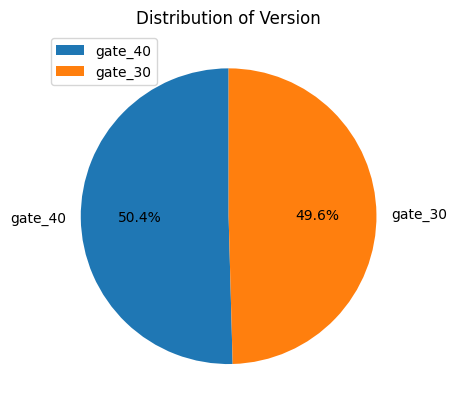

In [24]:
version_counts = df['version'].value_counts()
plt.pie(version_counts, labels=version_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Version')
plt.legend()
plt.show()

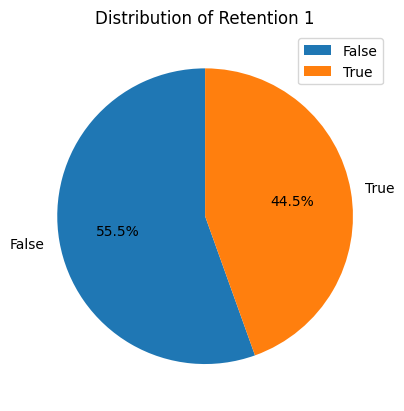

In [25]:
retention_1_counts= df['retention_1'].value_counts()
plt.pie(retention_1_counts, labels=retention_1_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Retention 1')
plt.legend()
plt.show()

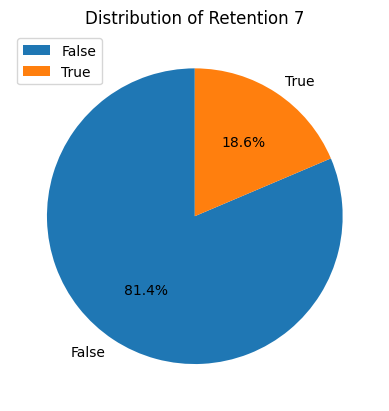

In [27]:
retention_7_counts= df['retention_7'].value_counts()
plt.pie(retention_7_counts, labels=retention_1_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Retention 7')
plt.legend()
plt.show()

In [28]:
# Retention Day 1
retention_d1 = df.groupby('version')['retention_1'].mean()
print(retention_d1)

# Retention Day 7
retention_d7 = df.groupby('version')['retention_7'].mean()
print(retention_d7)


version
gate_30    0.448188
gate_40    0.442283
Name: retention_1, dtype: float64
version
gate_30    0.190201
gate_40    0.182000
Name: retention_7, dtype: float64


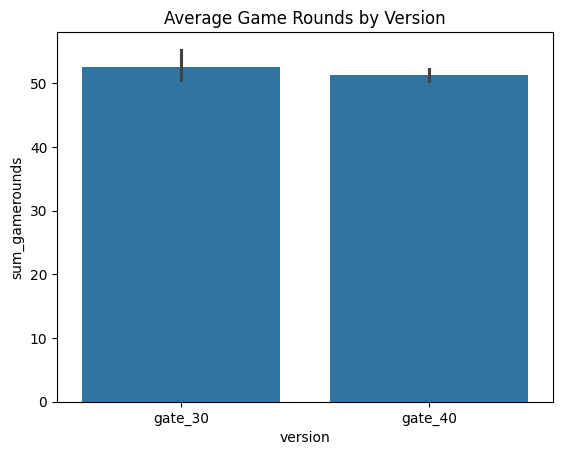

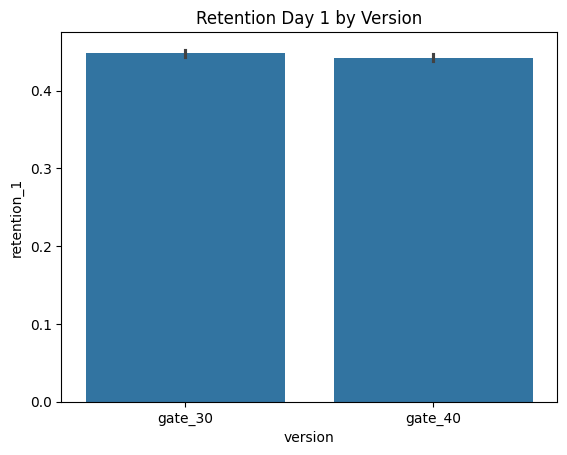

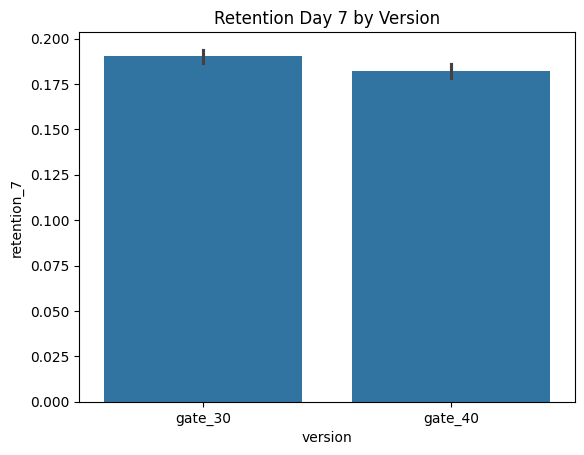

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart لمتوسط Engagement
sns.barplot(x='version', y='sum_gamerounds', data=df)
plt.title('Average Game Rounds by Version')
plt.show()

# Bar chart Retention D1
sns.barplot(x='version', y='retention_1', data=df)
plt.title('Retention Day 1 by Version')
plt.show()

# Bar chart Retention D7
sns.barplot(x='version', y='retention_7', data=df)
plt.title('Retention Day 7 by Version')
plt.show()


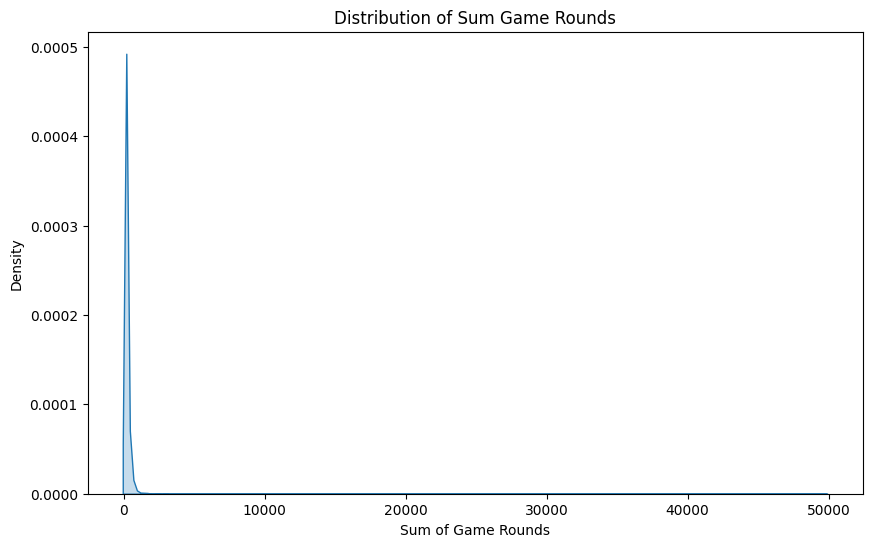

In [30]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['sum_gamerounds'], fill=True)
plt.title('Distribution of Sum Game Rounds')
plt.xlabel('Sum of Game Rounds')
plt.ylabel('Density')
plt.show()

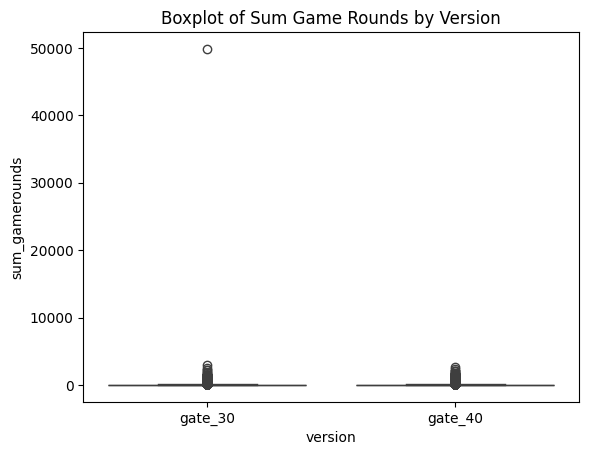

In [31]:
sns.boxplot(x='version', y='sum_gamerounds', data=df)
plt.title('Boxplot of Sum Game Rounds by Version')
plt.show()

In [32]:
# Check the actual max value and who it is
print(df['sum_gamerounds'].max())        # → 49854
print(df['sum_gamerounds'].sort_values(ascending=False).head(3))

# Remove the one extreme outlier (common practice in this exact dataset)
df_clean = df[df['sum_gamerounds'] < 45000].copy()
print(f"Original rows: {len(df)} → After outlier removal: {len(df_clean)}")

49854
57702    49854
7912      2961
29417     2640
Name: sum_gamerounds, dtype: int64
Original rows: 90189 → After outlier removal: 90188


In [33]:
df_clean.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


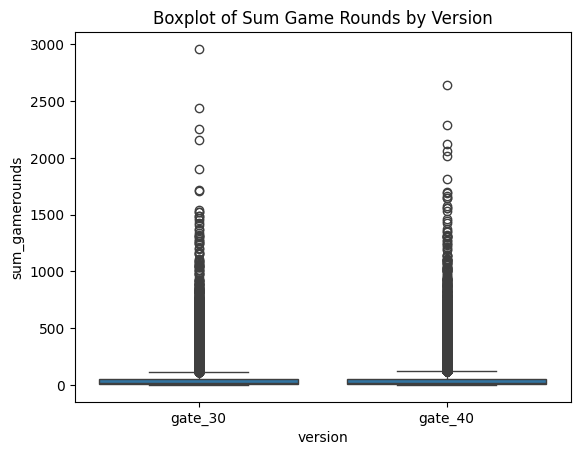

In [34]:
sns.boxplot(x='version', y='sum_gamerounds', data=df_clean)
plt.title('Boxplot of Sum Game Rounds by Version')
plt.show()

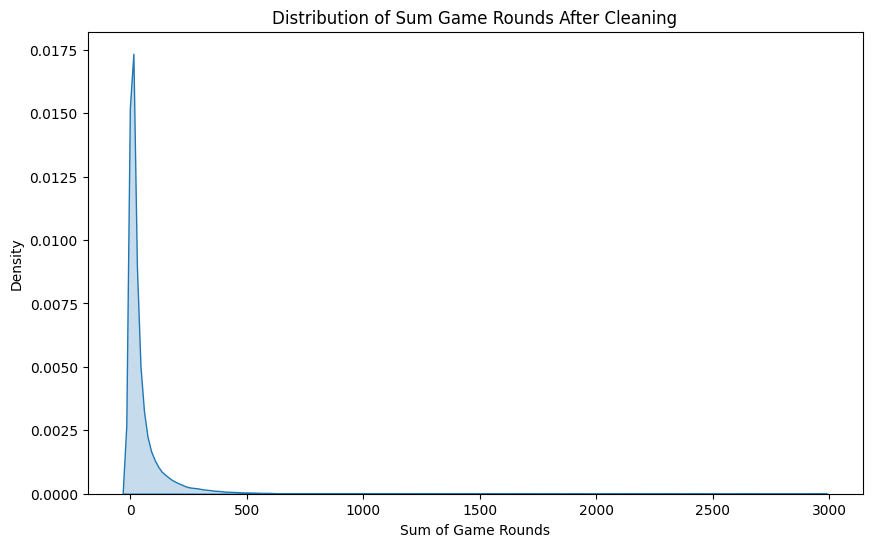

In [36]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_clean['sum_gamerounds'], fill=True)
plt.title('Distribution of Sum Game Rounds After Cleaning')
plt.xlabel('Sum of Game Rounds')
plt.ylabel('Density')
plt.show()

In [37]:
import scipy.stats as stats
import numpy as np

In [40]:
control = df_clean[df_clean['version'] == 'gate_30']
treatment = df_clean[df_clean['version'] == 'gate_40']

In [41]:
ret1_control = control['retention_1'].mean()
ret1_treatment = treatment['retention_1'].mean()

## Statistical Analysis

In [ ]:

import scipy.stats as stats
import pandas as pd

# Retention 1-day significance
contingency_1 = pd.crosstab(df['version'], df['retention_1'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_1)
print("Retention 1-day p-value:", p)

# Retention 7-day significance
contingency_7 = pd.crosstab(df['version'], df['retention_7'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_7)
print("Retention 7-day p-value:", p)

# T-test on gamerounds
gate30 = df[df['version'] == 'gate_30']['sum_gamerounds']
gate40 = df[df['version'] == 'gate_40']['sum_gamerounds']
print(stats.ttest_ind(gate30, gate40))

# Lift
ret30 = df[df['version']=='gate_30']['retention_7'].mean()
ret40 = df[df['version']=='gate_40']['retention_7'].mean()
lift = (ret40 - ret30) / ret30
print("Lift:", lift)



## 📌 Final Conclusion

The A/B test shows that moving the gate from level 30 to level 40 has a **negative impact** on player retention.

- **Day-1 retention:** No significant difference (p > 0.05)  
- **Day-7 retention:** Significantly lower for Gate 40 (p < 0.05)  
- **Total rounds:** No significant difference  
- **Lift:** Gate 40 reduces 7-day retention by around **4.31%**

### ✅ Recommendation
Keep the gate at **level 30** because moving it to level 40 causes a statistically significant drop in long-term retention.


## 🔍 Machine Learning Model: Random Forest
This section adds a predictive model to classify retention using a Random Forest classifier.

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

# Feature Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances)
